# Vegetation Data: Cleaning, Weather-Grid Mapping & Feature Extraction

**Purpose:** End-to-end pipeline that (1) maps raw vegetation classification data
onto the weather reanalysis grid, and (2) enriches each grid cell with parsed
vegetation class names and fire-attribute labels.

**Pipeline Overview:**

| Phase | Steps |
|-------|-------|
| **A. Grid Mapping** (from `00_Data_Clean`) | Load weather grid, load vegetation NetCDF, KD-Tree match, geodesic filter, save intermediate `.parquet` |
| **B. Feature Extraction** (from `02_01_Veg_Data_Extract`) | Parse `veg_type_details` into `veg` + `fire_attribute`, merge onto grid data, save final `.parquet` |

**Inputs:**

| Data | Path |
|------|------|
| Weather `.nc` files (for grid) | `E:/zcao/CA_Wildfire/climate_merged/` |
| Vegetation NetCDF | `E:/zcao/CA_Wildfire/Vegetation_Data/Vegetation.nc` |
| Vegetation type lookup | `E:/zcao/CA_Wildfire/Vegetation_Data/veg_mapping.csv` |

**Outputs:**

| Data | Path |
|------|------|
| Intermediate: grid + veg type | `<output_dir>/Veg_Data/lon_lat_pair_weather_match_veg.parquet` |
| Cleaned mapping table | `<output_dir>/Veg_Data/veg_mapping_cleaned.csv` |
| Final: grid + veg + fire attribute | `<output_dir>/Veg_Data/lon_lat_pair_weather_match_veg_v2.parquet` |

## 0. Configuration

Centralized path configuration — **edit this cell only** to adapt to your local setup.

In [18]:
import os

# ====================== EDIT THESE PATHS ======================
PROJECT_ROOT = r"E:\zcao\CA_Wildfire"

# Input paths
WEATHER_DIR       = os.path.join(PROJECT_ROOT, "climate_merged")
VEG_NC_PATH       = os.path.join(PROJECT_ROOT, "Vegetation_Data", "Vegetation.nc")
VEG_MAPPING_PATH  = os.path.join(PROJECT_ROOT, "Vegetation_Data", "veg_mapping.csv")

# Output path
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "Clean_Data\Veg_Data")

# Processing parameters
MAX_MATCH_DISTANCE_KM = 2  # drop grid cells whose nearest veg pixel is farther than this
# ==============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Input paths:")
for label, path in [("Weather dir", WEATHER_DIR),
                     ("Vegetation NC", VEG_NC_PATH),
                     ("Veg mapping CSV", VEG_MAPPING_PATH)]:
    exists = os.path.exists(path)
    status = "\u2713" if exists else "\u2717 NOT FOUND"
    print(f"  {status}  {label}: {path}")
print(f"\nOutput dir: {OUTPUT_DIR}")

Input paths:
  ✓  Weather dir: E:\zcao\CA_Wildfire\climate_merged
  ✓  Vegetation NC: E:\zcao\CA_Wildfire\Vegetation_Data\Vegetation.nc
  ✓  Veg mapping CSV: E:\zcao\CA_Wildfire\Vegetation_Data\veg_mapping.csv

Output dir: E:\zcao\CA_Wildfire\Clean_Data\Veg_Data


## 1. Environment Setup

In [2]:
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import pyproj
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from geopy.distance import geodesic
from tqdm import tqdm

pd.set_option("display.max_colwidth", None)

print(f"Python     : {sys.version.split(chr(124))[0].strip()}")
print(f"pandas     : {pd.__version__}")
print(f"xarray     : {xr.__version__}")
print(f"numpy      : {np.__version__}")
print(f"geopandas  : {gpd.__version__}")
print(f"pyproj     : {pyproj.__version__}")

Python     : 3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]
pandas     : 2.2.2
xarray     : 2024.7.0
numpy      : 1.24.4
geopandas  : 0.14.3
pyproj     : 3.6.1


---

# Phase A: Weather-Grid Mapping

Map each weather grid cell to its nearest vegetation pixel, then filter
out ocean / out-of-domain cells by geodesic distance.

## 2. Load Weather Grid

Extract the (lon, lat) coordinate grid from a reference weather NetCDF file.
This grid defines the spatial resolution for all downstream analysis.

In [19]:
# Auto-detect a .nc file from the weather directory
nc_files = sorted([f for f in os.listdir(WEATHER_DIR) if f.endswith(".nc")])
assert len(nc_files) > 0, f"No .nc files found in {WEATHER_DIR}"

nc_path = os.path.join(WEATHER_DIR, nc_files[0])
print(f"Reference file: {nc_files[0]}")

reference_ds = xr.open_dataset(nc_path)

print(f"Dimensions : {dict(reference_ds.dims)}")
print(f"Coordinates: {list(reference_ds.coords)}")
print(f"Variables  : {list(reference_ds.data_vars)}")

Reference file: dead_fuel_moisture_1000h.1994.2000.CA.nc
Dimensions : {'lon': 258, 'lat': 238, 'day': 2557, 'crs': 1}
Coordinates: ['lon', 'lat', 'day', 'crs', 'year']
Variables  : ['dead_fuel_moisture_1000hr']


In [20]:
# Extract coordinate arrays (handle both naming conventions)
lon_name = "lon" if "lon" in reference_ds.coords else "longitude"
lat_name = "lat" if "lat" in reference_ds.coords else "latitude"
lon = reference_ds.coords[lon_name].values
lat = reference_ds.coords[lat_name].values

# Build all (lon, lat) combinations using meshgrid (vectorized)
lon_grid, lat_grid = np.meshgrid(lon, lat)
weather_grid = pd.DataFrame({
    "lon": lon_grid.ravel(),
    "lat": lat_grid.ravel(),
})

print(f"Grid size: {len(lon)} lon x {len(lat)} lat = {len(weather_grid):,} cells")
print(f"Lon range: [{lon.min():.3f}, {lon.max():.3f}]")
print(f"Lat range: [{lat.min():.3f}, {lat.max():.3f}]")
weather_grid.head()

Grid size: 258 lon x 238 lat = 61,404 cells
Lon range: [-124.683, -113.975]
Lat range: [32.317, 42.192]


,lon,lat
0,-124.683333,42.191667
1,-124.641667,42.191667
2,-124.600000,42.191667
3,-124.558333,42.191667
4,-124.516667,42.191667


## 3. Load & Clean Vegetation Data

### 3a. Load the vegetation NetCDF

The vegetation dataset contains a gridded `type` field (integer codes).
We convert it to a flat DataFrame and drop cells with missing type codes.

In [21]:
vegetation_ds = xr.open_dataset(VEG_NC_PATH)
print(vegetation_ds)

<xarray.Dataset> Size: 192kB
Dimensions:  (lon: 205, lat: 230)
Coordinates:
  * lon      (lon) float64 2kB -124.4 -124.4 -124.3 ... -116.0 -116.0 -115.9
  * lat      (lat) float64 2kB 42.08 42.04 41.99 41.95 ... 32.62 32.58 32.54
Data variables:
    type     (lat, lon) float32 189kB ...
Attributes:
    Conventions:      CF-1.0
    Source_Software:  Esri ArcGIS


In [22]:
vegetation_dat = vegetation_ds.to_dataframe().reset_index()

na_pct = vegetation_dat["type"].isna().mean() * 100
print(f"Raw shape: {vegetation_dat.shape[0]:,} rows")
print(f"Missing 'type': {na_pct:.2f}%")

vegetation_dat = vegetation_dat.dropna(subset=["type"])
print(f"After dropping NAs: {vegetation_dat.shape[0]:,} rows")

Raw shape: 47,150 rows
Missing 'type': 62.43%
After dropping NAs: 17,714 rows


### 3b. Load Vegetation Type Lookup

Load the mapping CSV that translates integer type codes to vegetation class names.
A simple merge is done here; the detailed parsing happens in Phase B.

In [23]:
veg_mapping_raw = pd.read_csv(VEG_MAPPING_PATH, header=None, names=["type", "veg_type"])
print(f"Mapping table: {len(veg_mapping_raw)} classes")

vegetation_dat = vegetation_dat.merge(veg_mapping_raw, on="type")
print(f"After merge: {vegetation_dat.shape[0]:,} rows x {vegetation_dat.shape[1]} cols")
vegetation_dat.head()

Mapping table: 39 classes
After merge: 17,714 rows x 4 cols


,lon,lat,type,veg_type
0,-124.374975,40.452058,7.0,Native Coastal Sage Scrub - fire
1,-124.374975,40.410392,25.0,Native Oak Woodland - fire
2,-124.333309,40.577058,1.0,Agriculture - low
3,-124.333309,40.535392,8.0,Native Coastal Sage Scrub - mesic
4,-124.333309,40.493725,25.0,Native Oak Woodland - fire


### 3c. Quick Look: Vegetation Type Map

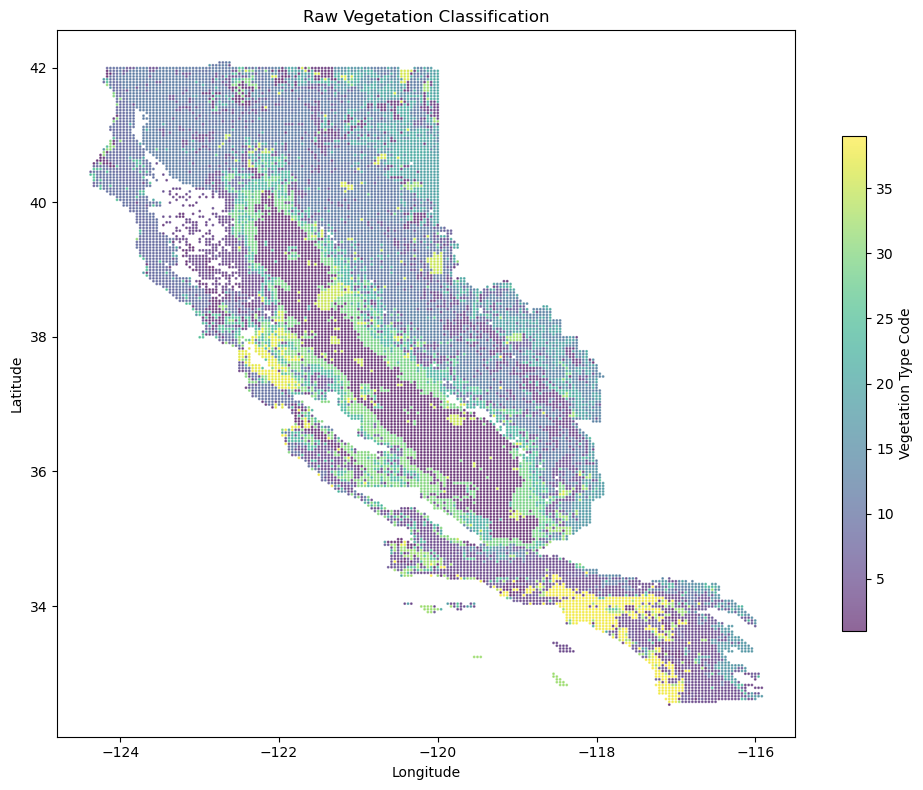

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    vegetation_dat["lon"], vegetation_dat["lat"],
    c=vegetation_dat["type"], cmap="viridis", s=1, alpha=0.6,
)
fig.colorbar(sc, ax=ax, label="Vegetation Type Code", shrink=0.7)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Raw Vegetation Classification")
plt.tight_layout()
plt.show()

## 4. Map Weather Grid to Nearest Vegetation Pixel

### 4a. KD-Tree Approximate Nearest-Neighbor Search

For each weather grid cell, find the closest vegetation pixel.
The KD-Tree operates in (lat, lon) coordinate space for a fast initial match.

In [25]:
# Build KD-Tree on vegetation coordinates
tree = cKDTree(vegetation_dat[["lat", "lon"]].values)

# Query nearest neighbor for every weather grid cell
approx_distances, indices = tree.query(weather_grid[["lat", "lon"]].values, k=1)

print(f"Approximate distance range: [{approx_distances.min():.4f}, {approx_distances.max():.4f}] (degrees)")

Approximate distance range: [0.0197, 5.9611] (degrees)


### 4b. Compute Exact Geodesic Distances

Convert the approximate degree-based distances to true geodesic distances (km)
for accurate quality filtering.

In [26]:
exact_distances = np.empty(len(weather_grid))
grid_coords = weather_grid[["lat", "lon"]].values
veg_coords = vegetation_dat[["lat", "lon"]].values

for i in tqdm(range(len(weather_grid)), desc="Geodesic distances"):
    exact_distances[i] = geodesic(
        (grid_coords[i, 0], grid_coords[i, 1]),
        (veg_coords[indices[i], 0], veg_coords[indices[i], 1]),
    ).km

print(f"\nExact distance range: [{exact_distances.min():.3f}, {exact_distances.max():.3f}] km")

Geodesic distances: 100%|██████████| 61404/61404 [00:10<00:00, 5883.85it/s]


Exact distance range: [1.800, 574.092] km


### 4c. Assign Vegetation Type & Filter by Distance

Grid cells whose nearest vegetation pixel is more than `MAX_MATCH_DISTANCE_KM` (2 km)
away are likely over ocean or outside the vegetation domain — these are set to NaN.

In [27]:
mask = exact_distances < MAX_MATCH_DISTANCE_KM

weather_grid["type"]     = np.where(mask, vegetation_dat.iloc[indices]["type"].values, np.nan)
weather_grid["distance"] = np.where(mask, exact_distances, np.nan)

matched_pct = mask.sum() / len(mask) * 100
dropped_pct = 100 - matched_pct
print(f"Matched (< {MAX_MATCH_DISTANCE_KM} km): {mask.sum():,} / {len(mask):,} ({matched_pct:.1f}%)")
print(f"Dropped (>= {MAX_MATCH_DISTANCE_KM} km): {(~mask).sum():,} ({dropped_pct:.1f}%)")

Matched (< 2 km): 17,714 / 61,404 (28.8%)
Dropped (>= 2 km): 43,690 (71.2%)


## 5. Visualization: Before vs. After Grid Mapping

Compare the raw vegetation data (right) with the weather-grid-mapped version (left).
The left panel should show the same spatial pattern but on the coarser weather grid,
with ocean/border cells removed.

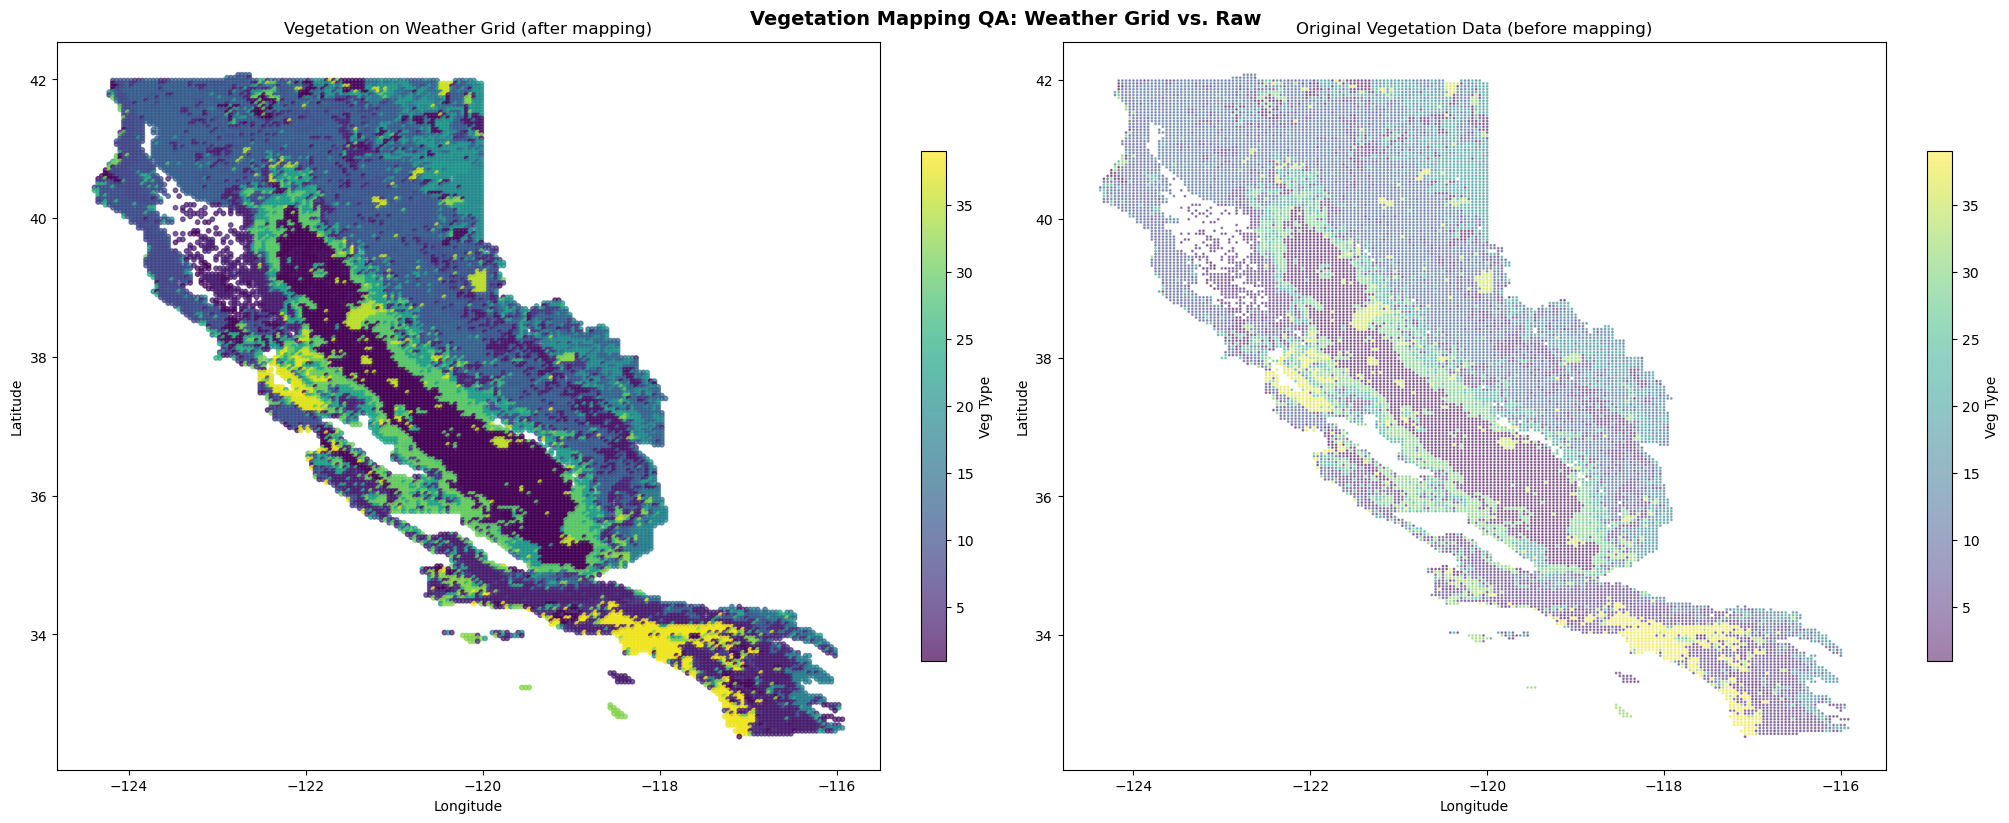

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

# Left: mapped to weather grid
mapped = weather_grid.dropna(subset=["type"])
sc1 = axes[0].scatter(
    mapped["lon"], mapped["lat"],
    c=mapped["type"], cmap="viridis", s=10, alpha=0.7,
)
axes[0].set_title("Vegetation on Weather Grid (after mapping)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(sc1, ax=axes[0], label="Veg Type", shrink=0.7)

# Right: original vegetation
sc2 = axes[1].scatter(
    vegetation_dat["lon"], vegetation_dat["lat"],
    c=vegetation_dat["type"], cmap="viridis", s=1, alpha=0.5,
)
axes[1].set_title("Original Vegetation Data (before mapping)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
fig.colorbar(sc2, ax=axes[1], label="Veg Type", shrink=0.7)

plt.suptitle("Vegetation Mapping QA: Weather Grid vs. Raw", fontsize=14, fontweight="bold", y=1.01)
plt.show()

### Save Phase A Output

In [29]:
weather_grid_clean = weather_grid.dropna(subset=["type"])

rows_removed = len(weather_grid) - len(weather_grid_clean)
print(f"Rows before cleaning: {len(weather_grid):,}")
print(f"Rows removed (NaN):   {rows_removed:,}")
print(f"Rows after cleaning:  {len(weather_grid_clean):,}")

phase_a_path = os.path.join(OUTPUT_DIR, "lon_lat_pair_weather_match_veg.parquet")
weather_grid_clean.to_parquet(phase_a_path, index=False)

print(f"\nSaved to: {phase_a_path}")
print(f"File size: {os.path.getsize(phase_a_path) / 1e6:.2f} MB")

Rows before cleaning: 61,404
Rows removed (NaN):   43,690
Rows after cleaning:  17,714

Saved to: E:\zcao\CA_Wildfire\Clean_Data\Veg_Data\lon_lat_pair_weather_match_veg.parquet
File size: 0.08 MB


---

# Phase B: Vegetation Feature Extraction

Parse the raw `veg_type_details` string into two useful columns:

- **`veg`** — the vegetation class name (e.g. `Shrub`, `Grass`)
- **`fire_attribute`** — the fire-behavior attribute after the last `-` (e.g. `fire`, `low`)

Then merge these features onto the grid-mapped data from Phase A.

## 6. Parse Vegetation Mapping Table

The `veg_type_details` field in `veg_mapping.csv` encodes both the vegetation class
and a fire attribute, separated by `-`. We split these into two columns.

In [30]:
veg_mapping = pd.read_csv(VEG_MAPPING_PATH, header=None, names=["type", "veg_type_details"])

# Parse: everything before the last '-' is the veg class, after it is the fire attribute
veg_mapping["fire_attribute"] = veg_mapping["veg_type_details"].str.split("-").str[-1]
veg_mapping["veg"]            = veg_mapping["veg_type_details"].str.rsplit("-", n=1).str[0]

print(f"Parsed {len(veg_mapping)} vegetation classes")
print()
veg_mapping

Parsed 39 vegetation classes



,type,veg_type_details,fire_attribute,veg
0,1,Agriculture - low,low,Agriculture
1,2,Agriculture - rarely,rarely,Agriculture
2,3,Barren - rarely,rarely,Barren
3,4,Native Chapparal - archetypical,archetypical,Native Chapparal
4,5,Native Chapparal - fire,fire,Native Chapparal
5,6,Native Coastal Sage Scrub - archetypical,archetypical,Native Coastal Sage Scrub
6,7,Native Coastal Sage Scrub - fire,fire,Native Coastal Sage Scrub
7,8,Native Coastal Sage Scrub - mesic,mesic,Native Coastal Sage Scrub
8,9,Native Conifer Alpine - fire,fire,Native Conifer Alpine
9,10,Native Conifer Alpine - low,low,Native Conifer Alpine


In [31]:
print("Fire attribute distribution:")
print(veg_mapping["fire_attribute"].value_counts().to_string())

Fire attribute distribution:
fire_attribute
fire            12
low              8
rarely           7
archetypical     5
mesic            5
never            2


### Save Cleaned Mapping Table

In [32]:
mapping_out_path = os.path.join(OUTPUT_DIR, "veg_mapping_cleaned.csv")
veg_mapping.to_csv(mapping_out_path, index=False)
print(f"Saved cleaned mapping to: {mapping_out_path}")

Saved cleaned mapping to: E:\zcao\CA_Wildfire\Clean_Data\Veg_Data\veg_mapping_cleaned.csv


## 7. Merge Parsed Features onto Grid Data

Join the Phase A grid-mapped vegetation data with the parsed mapping table
to add `veg`, `veg_type_details`, and `fire_attribute` columns.

In [33]:
# Load Phase A output
veg_data = pd.read_parquet(phase_a_path)
mapping  = pd.read_csv(mapping_out_path)

# Quick data quality checks
print("Missing rates:")
print(f"  veg_data: {veg_data.isnull().mean().to_dict()}")
print(f"  mapping:  {mapping.isnull().mean().to_dict()}")
print(f"  mapping 'type' unique: {mapping['type'].nunique()} (should equal {len(mapping)})")

Missing rates:
  veg_data: {'lon': 0.0, 'lat': 0.0, 'type': 0.0, 'distance': 0.0}
  mapping:  {'type': 0.0, 'veg_type_details': 0.0, 'fire_attribute': 0.0, 'veg': 0.0}
  mapping 'type' unique: 39 (should equal 39)


In [34]:
print(f"Before merge: {veg_data.shape}")
veg_data = veg_data.merge(mapping, on="type", how="left")
print(f"After merge:  {veg_data.shape}")
print()
veg_data.head()

Before merge: (17714, 4)
After merge:  (17714, 7)



,lon,lat,type,distance,veg_type_details,fire_attribute,veg
0,-122.766667,42.066667,10.0,1.800109,Native Conifer Alpine - low,low,Native Conifer Alpine
1,-122.725000,42.066667,10.0,1.800109,Native Conifer Alpine - low,low,Native Conifer Alpine
2,-122.683333,42.066667,11.0,1.800109,Native Conifer Forest - archetypical,archetypical,Native Conifer Forest
3,-122.641667,42.066667,12.0,1.800109,Native Conifer Forest - fire,fire,Native Conifer Forest
4,-122.891667,42.025000,17.0,1.800796,Native Desert - rarely,rarely,Native Desert


## 8. Save Final Output

In [35]:
final_path = os.path.join(OUTPUT_DIR, "lon_lat_pair_weather_match_veg_v2.parquet")
veg_data.to_parquet(final_path, index=False)

print(f"Saved final data to: {final_path}")
print(f"File size: {os.path.getsize(final_path) / 1e6:.2f} MB")
print(f"Final shape: {veg_data.shape[0]:,} rows x {veg_data.shape[1]} cols")
print(f"Columns: {list(veg_data.columns)}")

Saved final data to: E:\zcao\CA_Wildfire\Clean_Data\Veg_Data\lon_lat_pair_weather_match_veg_v2.parquet
File size: 0.11 MB
Final shape: 17,714 rows x 7 cols
Columns: ['lon', 'lat', 'type', 'distance', 'veg_type_details', 'fire_attribute', 'veg']


## 9. Summary

| Phase | Step | Description | Key Result |
|-------|------|-------------|------------|
| A | Weather Grid | Extract lon/lat from `.nc` | ~62k grid cells |
| A | Vegetation | Load & clean `Vegetation.nc` | Drop NA type codes |
| A | KD-Tree Match | Nearest veg pixel per grid cell | Fast approximate search |
| A | Geodesic Filter | Drop matches > 2 km | Remove ocean / out-of-domain |
| A | Save | `lon_lat_pair_weather_match_veg.parquet` | Intermediate output |
| B | Parse Mapping | Split `veg_type_details` into `veg` + `fire_attribute` | Feature extraction |
| B | Merge | Join parsed features onto grid data | Enriched dataset |
| B | Save | `lon_lat_pair_weather_match_veg_v2.parquet` | Final output |

**Next steps:** Merge this vegetation lookup with the fire ignition dataset
using `(lon, lat)` or `(NEAREST_LON, NEAREST_LAT)` as the join key,
then combine with climate variables for ignition-risk modeling.